# Diagnosing Bias and Variance 

The leftmost figure shows a high bias problem where the model is not capturing the patterns in the training data. As a result, you will have a high training and cross validation error. The rightmost figure, on the other hand, shows a high variance problem, where the model has overfit the training set. Thus, even though it has a low training error, it will perform poorly on new examples. That is indicated by a high cross validation error. The ideal model would be the figure in the middle, where it successfully learns from the training set and also generalizes well to unseen data. 

To fix a high bias problem, you can: 
* try adding polynomial features
* try getting additional features
* try decreasing the regularization parameters

To fix a high variance problem, you can: 
* try increasing the regularization parameter
* try smaller sets of features
* get more training examples

## Establishing Baseline Level of Performance

Before you can diagnose a model for high bias or high variance, it is usually helpful to first have an idea of what level of error you can reasonably get to. 
* human level performance
* competing algorithm's performance
* guess based on the experience.

Real-world data can be very noisy and it's often infeasible to get to 0% error. For example, you might think that you have a high bias problem because you are getting 10% training and 15% cross validation error on a computer vision application. However, you later found out that even humans can't perform better than 10% error. If you consider this the baseline level, then you now instead have a variance problem because you've priortized minmizing the gap between cross validation and training error. 

In [1]:
from sklearn.linear_model import LinearRegression, Ridge 
from sklearn.preprocessing import StandardScaler, PolynomialFeatures 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
import numpy as np

In [2]:
def prepare_dataset(filename): 
    data = np.loadtxt(filename, delimiter = ",") 

    x = data[:, :-1] 
    y = data[:, -1] 

    x_train, x_, y_train, y_ = train_test_split(x, y, test_size=0.4, random_state=80) 

    x_cv, x_test, y_cv, y_test = train_test_split(x_, y_, test_size=0.5, random_state=80) 

    return x_train, y_train, x_cv, y_cv, x_test, y_test

In [3]:
def train_plot_poly(model, x_train, y_train, x_cv, y_cv, max_degree = 10, baseline = None): 
    train_mses = []
    cv_mses = []
    models = []
    scalers = []
    degrees = range(1, max_degree + 1) 

    for degree in degrees: 
        poly = PolynomialFeatures(degree, include_bias=False) 
        X_train_mapped = poly.fit_transform(x_train) 

        scaler_poly = StandardScaler() 
        X_train_mapped_scaled = scaler_poly.fit_transform(X_train_mapped) 

        model.fit(X_train_mapped_scaled, y_train) 
        models.append(model) 

        yhat = model.predict(X_train_mapped_scaled) 
        train_mse = mean_squared_error(y_train, yhat) / 2
        train_mses.append(train_mse) 

        poly = PolynomialFeatures(degree, include_bias = False) 
        X_cv_mapped = poly.fit_transform(x_cv) 
        X_cv_mapped_scaled = scaler_poly.transform(X_cv_mapped) 

        yhat = model.predict(X_cv_mapped_scaled) 
        cv_mse = mean_squared_error(y_cv, yhat) / 2 
        cv_mses.append(cv_mse)
        
    plt.plot(degrees, train_mses, marker = 'o', c= 'r', label = 'training MSEs') 
    plt.plot(degrees, cv_mses, marker = 'o', c= 'b', label = 'CV MSEs') 
    plt.plot(degrees, np.repeat(baseline, len(degrees)), linestyle = '--', label = 'baseline') 
    plt.title("degree of polynomial vs. train and CV MSEs") 
    plt.xticks(degrees) 
    plt.ylabel("MSE") 
    plt.legend() 
    plt.show()

the shape of the training set (input) is: (60, 1)
the shape of the training set (target) is (60,)

the shape of the cross validation set (input) is: (20, 1)
the shape of the cross validation set (target) is (20,)

first 5 rows of the training inputs (1 feature): [[3757.57575758]
 [2878.78787879]
 [3545.45454545]
 [1575.75757576]
 [1666.66666667]]



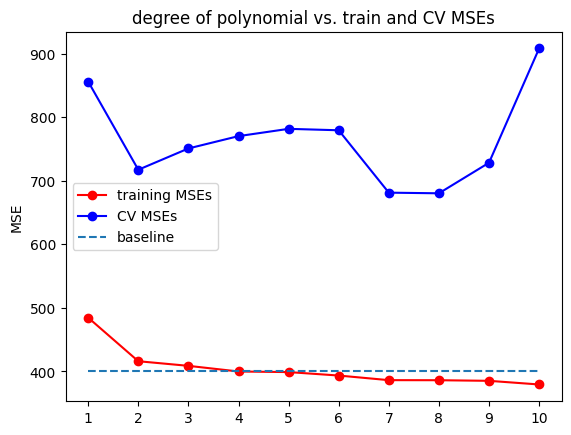

In [4]:
x_train, y_train, x_cv, y_cv, x_test, y_test = prepare_dataset('data/c2w3_lab2_data1.csv')

print(f"the shape of the training set (input) is: {x_train.shape}")
print(f"the shape of the training set (target) is {y_train.shape}\n")
print(f"the shape of the cross validation set (input) is: {x_cv.shape}")
print(f"the shape of the cross validation set (target) is {y_cv.shape}\n")

print(f"first 5 rows of the training inputs (1 feature): {x_train[:5]}\n")

model = LinearRegression()
train_plot_poly(model, x_train, y_train, x_cv, y_cv, max_degree=10, baseline=400) 

As you can see, the more polynomial features you add, the better the model fits to the training data. In this example, it even performed better than the baseline. At this point, you ocan say that the models with degree greater than 4 are low bias because they perform close or better than the baseline. 

However, if the baseline is defined lower, then the models are still considered high bias. You can then try other methods to impve this.

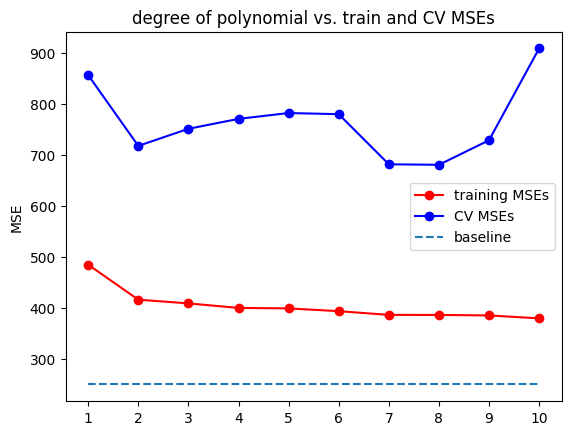

In [5]:
train_plot_poly(model, x_train, y_train, x_cv, y_cv, max_degree = 10, baseline=250) 

### Try getting additional features 
Another thing you can try is to acquire other features. Let's say that after you got the results above, you decided to launch another data collection campaign that captures another features. Your dataset will now have 2 columns for the input features as show below

In [6]:
x_train, y_train, x_cv, y_cv, x_test, y_test = prepare_dataset("data/c2w3_lab2_data2.csv")

print(f"the shape of the training set (input) is: {x_train.shape}")
print(f"the shape of the training set (target) is {y_train.shape}\n")
print(f"the shape of the cross validation set (input) is: {x_cv.shape}")
print(f"the shape of the cross validation set (target) is {y_cv.shape}\n")

print(f"first 5 rows of the training inputs (1 feature): {x_train[:5]}\n")

the shape of the training set (input) is: (60, 2)
the shape of the training set (target) is (60,)

the shape of the cross validation set (input) is: (20, 2)
the shape of the cross validation set (target) is (20,)

first 5 rows of the training inputs (1 feature): [[3.75757576e+03 5.49494949e+00]
 [2.87878788e+03 6.70707071e+00]
 [3.54545455e+03 3.71717172e+00]
 [1.57575758e+03 5.97979798e+00]
 [1.66666667e+03 1.61616162e+00]]



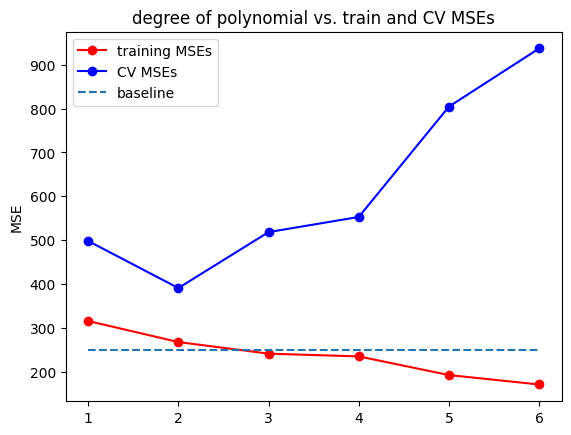

In [7]:
model = LinearRegression() 

train_plot_poly(model, x_train, y_train, x_cv, y_cv, max_degree=6, baseline=250)

In [8]:
def train_plot_reg_params(reg_params, x_train, y_train, x_cv, y_cv, degree = 1, baseline=None): 
    train_mses = []
    cv_mses = []
    models = []
    scalers = []

    for reg_param in reg_params: 
        poly = PolynomialFeatures(degree, include_bias=False) 
        X_train_mapped = poly.fit_transform(x_train) 

        scaler_poly = StandardScaler() 
        X_train_mapped_scaled = scaler_poly.fit_transform(X_train_mapped) 
        scalers.append(scaler_poly) 

        model = Ridge(alpha=reg_param) 
        model.fit(X_train_mapped_scaled, y_train) 
        models.append(model) 

        yhat = model.predict(X_train_mapped_scaled) 
        train_mse = mean_squared_error(y_train, yhat) / 2
        train_mses.append(train_mse) 

        poly = PolynomialFeatures(degree, include_bias=False) 
        X_cv_mapped = poly.fit_transform(x_cv) 
        X_cv_mapped_scaled = scaler_poly.transform(X_cv_mapped) 

        yhat = model.predict(X_cv_mapped_scaled) 
        cv_mse = mean_squared_error(y_cv, yhat) / 2
        cv_mses.append(cv_mse) 

    reg_params = [str(x) for x in reg_params]
    plt.plot(reg_params, train_mses, marker = 'o', c = 'r', label='training MSEs') 
    plt.plot(reg_params, cv_mses, marker = 'o', c='b', label = 'CV MSEs') 
    plt.plot(reg_params, np.repeat(baseline, len(reg_params)), linestyle='--', label='baseline') 
    plt.title("lambda vs. train and CV MSEs") 
    plt.xlabel("lambda") 
    plt.ylabel("MSE") 
    plt.show()

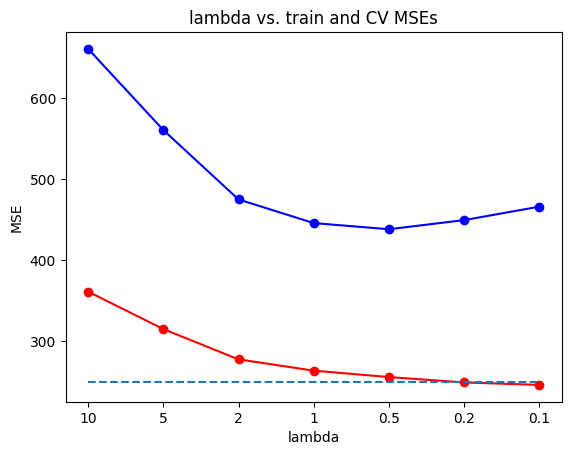

In [9]:
reg_params = [10, 5, 2, 1, 0.5, 0.2, 0.1]

train_plot_reg_params(reg_params, x_train, y_train, x_cv, y_cv, degree = 4, baseline=250) 

The resulting plot shows an initial $\lambda$ of `10` and as you can see, the training error is worse than the base line at that point. This implies that it is placing a huge penalty on the `w` parameters and this prevents the model from learning more complex patterns in your data. As you decrease $\lambda$, the model loosens this restrictions and the training error is able to approach the baseline performance. 

### Try increasing the regularization parameter 

In contrast to the last exercise above, setting a very small value of the regularaization parameter will keep the model low bias but might not do much to improve the variance. As shown below, you can improve your cross validation error by increasing the value of $\lambda$

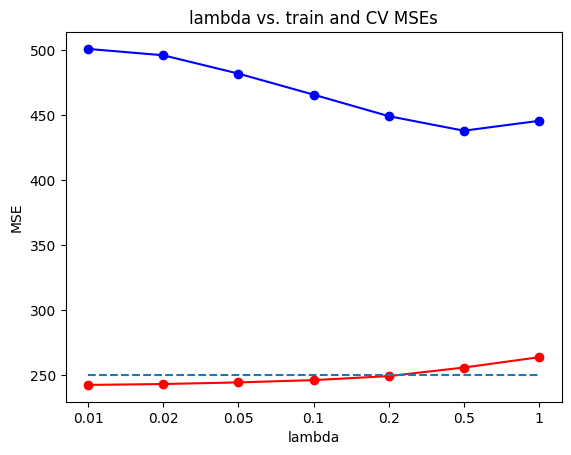

In [10]:
reg_params = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1]

train_plot_reg_params(reg_params, x_train, y_train, x_cv, y_cv, degree = 4, baseline = 250) 

In [11]:
x_train, y_train, x_cv, y_cv, x_test, y_test = prepare_dataset('data/c2w3_lab2_data2.csv') 

print(f"first 5 rows of the training set with 2 features:\n {x_train[:5]}\n")

x_train, y_train, x_cv, y_cv, x_test, y_test = prepare_dataset('data/c2w3_lab2_data3.csv')

print(f"first 5 rows of the training set with 3 features (1st column is a random ID):\n {x_train[:5]}\n")

first 5 rows of the training set with 2 features:
 [[3.75757576e+03 5.49494949e+00]
 [2.87878788e+03 6.70707071e+00]
 [3.54545455e+03 3.71717172e+00]
 [1.57575758e+03 5.97979798e+00]
 [1.66666667e+03 1.61616162e+00]]

first 5 rows of the training set with 3 features (1st column is a random ID):
 [[1.41929130e+07 3.75757576e+03 5.49494949e+00]
 [1.51868310e+07 2.87878788e+03 6.70707071e+00]
 [1.92662630e+07 3.54545455e+03 3.71717172e+00]
 [1.25222490e+07 1.57575758e+03 5.97979798e+00]
 [1.76537960e+07 1.66666667e+03 1.61616162e+00]]



In [12]:
def train_plot_diff_datasets(model, files, max_degree = 10, baseline = None): 
    for file in files: 
        x_train, y_train, x_cv, y_cv, x_test, y_test = prepare_dataset(file['filename']) 

        train_mses = []
        cv_mses = []
        models = []
        scalers = []
        degrees = range(1, max_degree + 1) 

        for degree in degrees: 
            poly = PolynomialFeatures(degree, include_bias=False) 
            X_train_mapped = poly.fit_transform(x_train) 

            scaler_poly = StandardScaler() 
            X_train_mapped_scaled = scaler_poly.fit_transform(X_train_mapped) 
            scalers.append(model) 

            model.fit(X_train_mapped_scaled, y_train) 
            models.append(model)
            
            yhat = model.predict(X_train_mapped_scaled) 
            train_mse = mean_squared_error(y_train, yhat) / 2
            train_mses.append(train_mse) 

            poly = PolynomialFeatures(degree, include_bias = False) 
            X_cv_mapped = poly.fit_transform(x_cv) 
            X_cv_mapped_scaled = scaler_poly.transform(X_cv_mapped) 

            yhat = model.predict(X_cv_mapped_scaled) 
            cv_mse = mean_squared_error(y_cv, yhat) / 2
            cv_mses.append(cv_mse) 
        
        plt.plot(degrees, train_mses, marker = 'o', c='r', 
                linestyle = file['linestyle'], label = f"{file['label']} training MSEs"); 
        plt.plot(degrees, cv_mses, marker = 'o', c='b', 
                linestyle = file['linestyle'], label=f"{file['label']} CV MSEs")
        
    plt.plot(degrees, np.repeat(baseline, len(degrees)), linestyle = '--', label = 'baseline') 
    plt.title("degree of polynomial vs. train and CV MSEs") 
    plt.xticks(degrees) 
    plt.xlabel("degree"); 
    plt.ylabel("MSE");
    plt.legend() 
    plt.show()

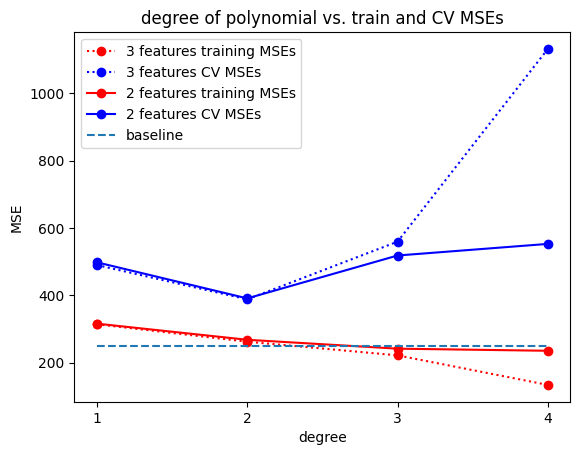

In [13]:
model = LinearRegression() 

file1 = {'filename' : 'data/c2w3_lab2_data3.csv', 'label' : '3 features', 'linestyle' : 'dotted'}
file2 = {'filename' : 'data/c2w3_lab2_data2.csv', 'label' : '2 features', 'linestyle' : 'solid'}
files = [file1, file2]

train_plot_diff_datasets(model, files, max_degree = 4, baseline=250) 

In [14]:
def train_plot_learning_curve(model, x_train, y_train, x_cv, y_cv, degree= 1, baseline=None):
    
    train_mses = []
    cv_mses = []
    models = []
    scalers = []
    num_samples_train_and_cv = []
    percents = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

    # Loop over 10 times. Each adding one more degree of polynomial higher than the last.
    for percent in percents:
        
        num_samples_train = round(len(x_train) * (percent/100.0))
        num_samples_cv = round(len(x_cv) * (percent/100.0))
        num_samples_train_and_cv.append(num_samples_train + num_samples_cv)
        
        x_train_sub = x_train[:num_samples_train]
        y_train_sub = y_train[:num_samples_train]
        x_cv_sub = x_cv[:num_samples_cv]
        y_cv_sub = y_cv[:num_samples_cv]

        # Add polynomial features to the training set
        poly = PolynomialFeatures(degree, include_bias=False)
        X_train_mapped = poly.fit_transform(x_train_sub)

        # Scale the training set
        scaler_poly = StandardScaler()
        X_train_mapped_scaled = scaler_poly.fit_transform(X_train_mapped)
        scalers.append(scaler_poly)

        # Create and train the model
        model.fit(X_train_mapped_scaled, y_train_sub)
        models.append(model)

        # Compute the training MSE
        yhat = model.predict(X_train_mapped_scaled)
        train_mse = mean_squared_error(y_train_sub, yhat) / 2
        train_mses.append(train_mse)

        # Add polynomial features and scale the cross-validation set
        poly = PolynomialFeatures(degree, include_bias=False)
        X_cv_mapped = poly.fit_transform(x_cv_sub)
        X_cv_mapped_scaled = scaler_poly.transform(X_cv_mapped)

        # Compute the cross-validation MSE
        yhat = model.predict(X_cv_mapped_scaled)
        cv_mse = mean_squared_error(y_cv_sub, yhat) / 2
        cv_mses.append(cv_mse)

    plt.plot(num_samples_train_and_cv, train_mses, marker = 'o', c='r', label='training MSEs') 
    plt.plot(num_samples_train_and_cv, cv_mses, marker = 'o', c='b', label='CV MSEs') 
    plt.plot(num_samples_train_and_cv, np.repeat(baseline, len(percents)), linestyle='--', label='baseline') 
    plt.title("number of examples vs. train and CV MSEs") 
    plt.xlabel("total number of training and examples") 
    plt.ylabel("MSE")
    plt.legend() 
    plt.show()

the shape of the training set (input) is: (600, 2)
the shape of the training set (target) is (600,)

the shape of the cross validation set (input) is: (200, 2)
the shape of the cross validation set (target) is (200,)



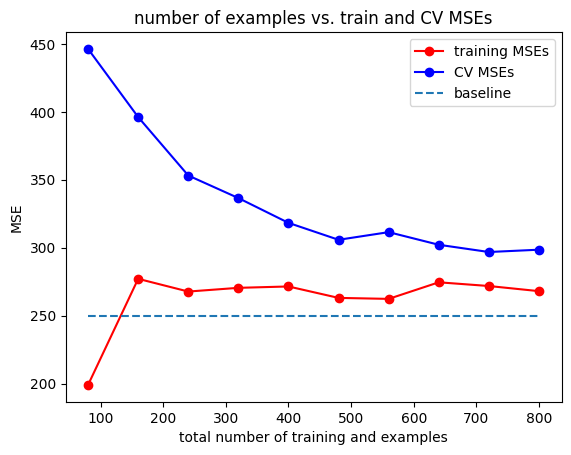

In [15]:
x_train, y_train, x_cv, y_cv, x_test, y_test = prepare_dataset('data/c2w3_lab2_data4.csv') 

print(f"the shape of the training set (input) is: {x_train.shape}")
print(f"the shape of the training set (target) is {y_train.shape}\n")
print(f"the shape of the cross validation set (input) is: {x_cv.shape}")
print(f"the shape of the cross validation set (target) is {y_cv.shape}\n")

model = LinearRegression() 
train_plot_learning_curve(model, x_train, y_train, x_cv, y_cv, degree = 4, baseline=250) 

From the results, it shows that the cross validation error starts to approach the training error as you increase the dataset size. Another insight you can get from this is that adding more examples will not likely solve a high bias problem. That's because the training error remains relatively flat even as the dataset increases. 